In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import umap
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from langdetect import detect
from sklearn.cluster import KMeans
from collections import Counter

In [2]:
# Read the CSV file
labeled_df = pd.read_csv("labeled_df.csv", sep=";")

# Check the first few rows
labeled_df.head()

,University Name,Review Date,Review Text,Timestamp,Year,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality,Cleaned_Text,Lemmatized_Text
0,University_1,2021-12-09,По информационному праву Токарева Ксения Серге...,2021-12-09,2021,1.0,0.0,0.0,0.0,0.0,по информационному праву токарева ксения серге...,информационный право токарев ксения сергеевич ...
1,University_1,2021-08-25,Людоньки це *****. Моя дочку поселили в кімнат...,2021-08-25,2021,0.0,1.0,0.0,0.0,0.0,людоньки це моя дочку поселили в кімнату з дів...,людоньки дочка поселити кімната дівчина NUM хл...
2,University_1,2019-06-08,"Шановні вступники, якщо ви хочете зберегти сво...",2019-06-08,2019,1.0,1.0,0.0,0.0,0.0,шановні вступники якщо ви хочете зберегти свої...,шановний вступник хотіти зберегти нерв здоров’...
3,University_1,2019-05-25,Советую ПРОКУРАТУРЕ проверить отдел закупок чт...,2019-05-25,2019,0.0,0.0,1.0,0.0,0.0,советую прокуратуре проверить отдел закупок чт...,советовать прокуратура проверить отдел закупка...
4,University_1,2019-05-19,Не знаю як і хто а я звязав своє життя з НАУ я...,2019-05-19,2019,0.0,0.0,0.0,0.0,1.0,не знаю як і хто а я звязав своє життя з нау я...,не знати звязати життя студент гроші коментар ...


In [3]:
labeled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   University Name              509 non-null    object 
 1   Review Date                  509 non-null    object 
 2   Review Text                  509 non-null    object 
 3   Timestamp                    509 non-null    object 
 4   Year                         509 non-null    int64  
 5   Attitude_Towards_Students    509 non-null    float64
 6   Campus_conditions            509 non-null    float64
 7   Corruption                   509 non-null    float64
 8   Academic_Process_Management  509 non-null    float64
 9   Education_Quality            509 non-null    float64
 10  Cleaned_Text                 509 non-null    object 
 11  Lemmatized_Text              509 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 47.8+ KB


In [4]:
# Read the CSV file
unlabeled_df = pd.read_csv("unlabeled_df.csv", sep=";")

# Check the first few rows
unlabeled_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...


In [5]:
# Read the CSV file
full_df = pd.read_csv("full_df.csv", sep=";")

# Check the first few rows
full_df.head()

,University Name,Review Text,Timestamp,Year,Cleaned_Text,Lemmatized_Text,Attitude_Towards_Students,Campus_conditions,Corruption,Academic_Process_Management,Education_Quality
0,University_1,1. зміст навчання і предмети не відповідають с...,2024-10-14,2024,1 зміст навчання і предмети не відповідають сп...,NUM зміст навчання предмет не відповідати спец...,NaN,NaN,NaN,NaN,NaN
1,University_1,"Три года обучения дистанционно, хотя в других ...",2023-02-02,2023,три года обучения дистанционно хотя в других в...,три год обучение дистанционно другой вуз студе...,NaN,NaN,NaN,NaN,NaN
2,University_1,"Працюють лише старі як перед смертю, або ті ко...",2023-01-23,2023,працюють лише старі як перед смертю або ті ког...,працювати лише старий смерть немати куди більш...,NaN,NaN,NaN,NaN,NaN
3,University_1,"При поступлении отвратительное отношение, кажд...",2022-09-16,2022,при поступлении отвратительное отношение кажды...,поступление отвратительный отношение считать д...,NaN,NaN,NaN,NaN,NaN
4,University_1,Как бы ректор не заявлял о намерении соответст...,2021-12-15,2021,как бы ректор не заявлял о намерении соответст...,ректор не заявлять намерение соответствовать е...,NaN,NaN,NaN,NaN,NaN


# Class distribution

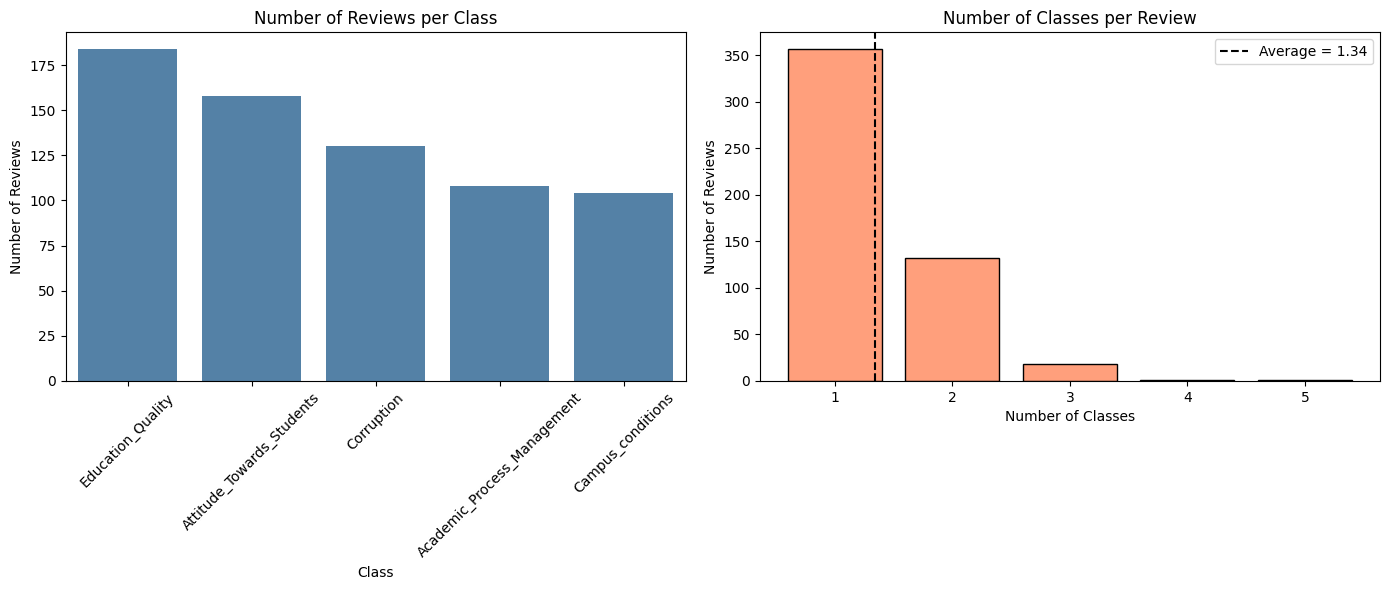

In [6]:
# Columns representing the classes
class_cols = [
    'Attitude_Towards_Students',
    'Campus_conditions',
    'Corruption',
    'Academic_Process_Management',
    'Education_Quality'
]

# Keep only rows that have at least one class labeled
df_labeled_only = labeled_df.dropna(subset=class_cols, how='all')

# 1️⃣ Count of reviews per class
class_counts = df_labeled_only[class_cols].sum().sort_values(ascending=False)
plot_df_counts = class_counts.reset_index()
plot_df_counts.columns = ['Class', 'Count']

# 2️⃣ Number of classes per review
num_classes = df_labeled_only[class_cols].sum(axis=1)
max_classes = int(num_classes.max())
bins = range(1, max_classes + 2)

# Calculate the average number of classes per review
avg_classes = num_classes.mean()

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — bar plot of counts per class
sns.barplot(data=plot_df_counts, x='Class', y='Count', color='steelblue', ax=axes[0])
axes[0].set_title("Number of Reviews per Class")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xlabel("Class")
axes[0].tick_params(axis='x', rotation=45)

# Right plot — histogram of number of classes per review
sns.histplot(num_classes, bins=bins, color='coral', discrete=True, shrink=0.8, ax=axes[1])
axes[1].axvline(avg_classes, color='black', linestyle='--', label=f"Average = {avg_classes:.2f}")
axes[1].set_title("Number of Classes per Review")
axes[1].set_xlabel("Number of Classes")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_xticks(bins[:-1])
axes[1].legend()

plt.tight_layout()
plt.show()

# Create a co-occurrence matrix
- This shows how often different categories are labeled together by users
- Understanding these patterns can directly influence model architecture decisions
- The interpretation of the results

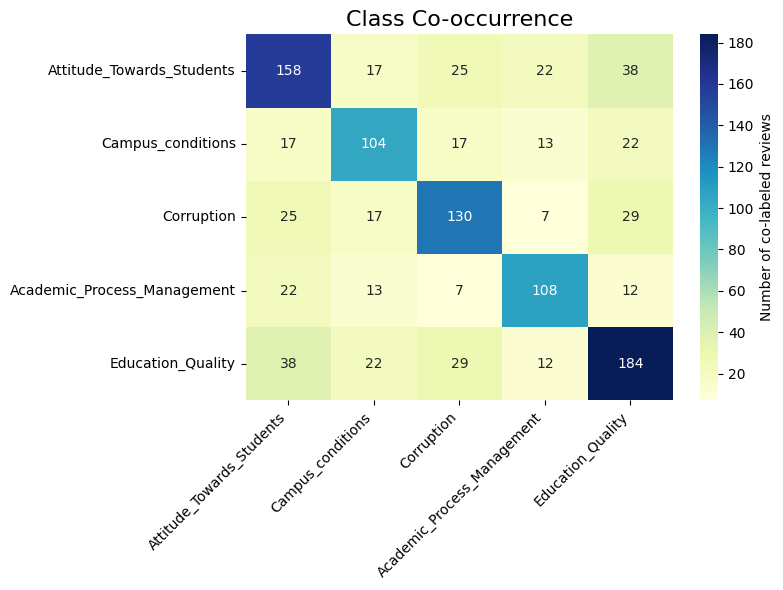

In [7]:
# Keep only rows that have at least one labeled class
df_labeled_only = labeled_df.dropna(subset=class_cols, how='all')

co_occurrence = df_labeled_only[class_cols].T.dot(df_labeled_only[class_cols])

# Convert to integer so heatmap annotations work properly
co_occurrence = co_occurrence.astype(int)

# Visualize co-occurrence matrix as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    co_occurrence, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Number of co-labeled reviews'}
)
plt.title("Class Co-occurrence", fontsize=16)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Class Co-Occurrence Network Visualization

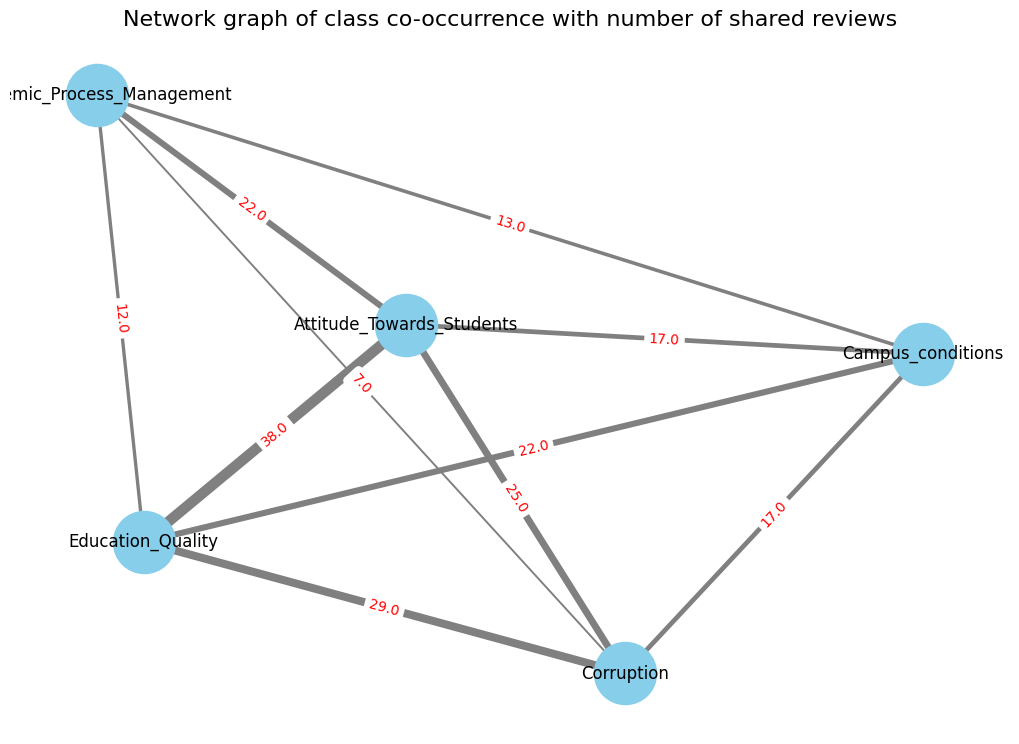

In [8]:
# Keep only labeled rows
df_labeled_only = labeled_df.dropna(subset=class_cols, how='all')

# Co-occurrence matrix
co_occurrence = df_labeled_only[class_cols].T.dot(df_labeled_only[class_cols])

# Set diagonal to 0
np.fill_diagonal(co_occurrence.values, 0)

# Create graph
G = nx.Graph()

# Add nodes
for cls in class_cols:
    G.add_node(cls)

# Add edges with weight = number of shared reviews
for i in class_cols:
    for j in class_cols:
        if i != j and co_occurrence.loc[i,j] > 0:
            G.add_edge(i, j, weight=co_occurrence.loc[i,j])

# Visualization
plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)  # node positions

# Edge thickness proportional to number of shared reviews
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]

nx.draw(
    G, pos, with_labels=True, node_color='skyblue', node_size=2000,
    edge_color='gray', width=[w/5 for w in weights], font_size=12
)

# Add numbers on edges
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title("Network graph of class co-occurrence with number of shared reviews", fontsize=16)
plt.show()

### Observation:

- Education_Quality shows strong co-appearance with Attitude_Towards_Students (38) and Corruption (29).

- Attitude_Towards_Students and Corruption also demonstrate notable co-appearance (25).

- The simultaneous co-appearance of classes suggests that the model might confuse these categories or predict them together.

# Review Clustering
### Goal of Review Clustering

**1. Explore the data structure in the vector space:**
- Do the reviews form natural clusters?  
- Do these clusters align with predefined classes (e.g., *“Corruption”* vs *“Education_Quality”*)?  
- Are the categories mixed → which would make classification more difficult?  

**2. Assess data quality:**
- Identify “noisy” points that do not resemble others in their class → these can be checked manually.  
- If two classes are heavily overlapping → their reviews might indeed share similar content.  

**3. Gain insights for modeling:**
- If clusters are well separated → even simple models might be sufficient.  
- If clusters are strongly mixed → more powerful approaches may be required (e.g., neural networks or fine-tuning LLMs).  

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


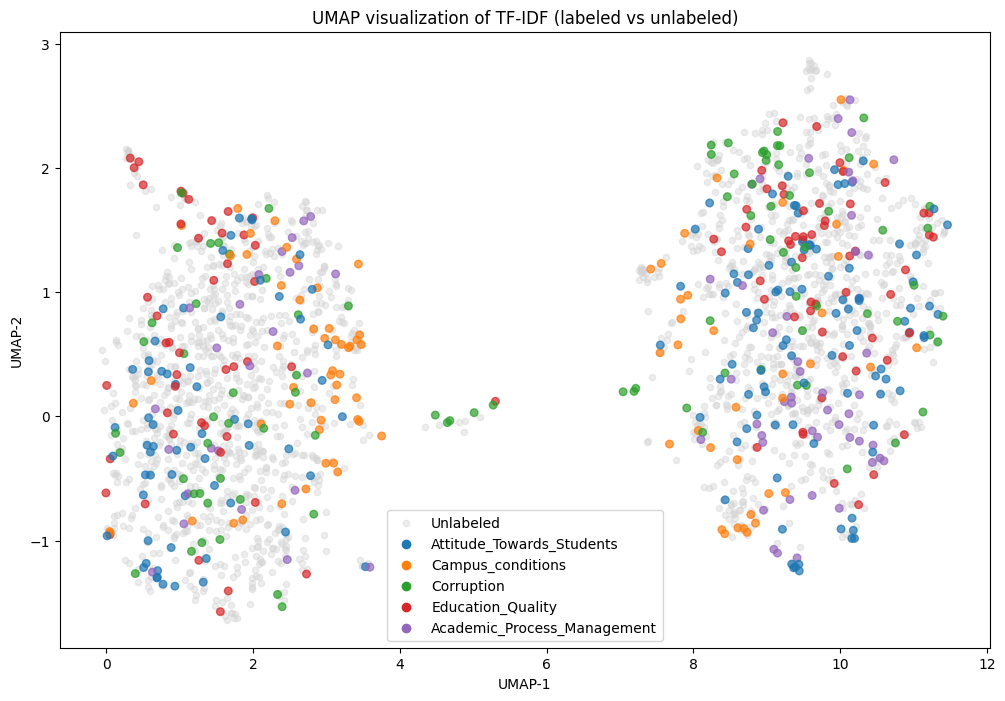

In [9]:
# Compute TF-IDF features for text data, reduces dimensionality to 2D using UMAP,
# and visualize labeled and unlabeled reviews in a scatter plot.
# Labeled points are colored by their class, while unlabeled points are shown in gray.

# 1. Compute TF-IDF for the entire corpus
# --------------------------
vectorizer = TfidfVectorizer(max_features=10000)  # max_features can be adjusted
tfidf_matrix = vectorizer.fit_transform(full_df["Lemmatized_Text"])  # result is a sparse matrix

# --------------------------
# 2. Reduce dimensionality to 2D using UMAP
# --------------------------
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
tfidf_2d = reducer.fit_transform(tfidf_matrix)

# --------------------------
# 3. Add 2D coordinates to the dataframe
# --------------------------
full_df["x"] = tfidf_2d[:, 0]
full_df["y"] = tfidf_2d[:, 1]

# --------------------------
# 4. Create masks for labeled and unlabeled reviews
# --------------------------
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

mask_labeled = full_df[label_cols].notna().any(axis=1)
mask_unlabeled = ~mask_labeled

# --------------------------
# 5. Assign a color for each class
# --------------------------
labels_series = full_df.loc[mask_labeled, label_cols].idxmax(axis=1)  # first active class
unique_labels = labels_series.unique()
palette = sns.color_palette("tab10", len(unique_labels))
color_dict = dict(zip(unique_labels, palette))
colors = labels_series.map(color_dict)

# --------------------------
# 6. Plot scatterplot
# --------------------------
plt.figure(figsize=(12, 8))

# Unlabeled reviews (gray)
plt.scatter(full_df.loc[mask_unlabeled, "x"],
            full_df.loc[mask_unlabeled, "y"],
            c="lightgray", alpha=0.4, s=20, label="Unlabeled")

# Labeled reviews (colored)
plt.scatter(full_df.loc[mask_labeled, "x"],
            full_df.loc[mask_labeled, "y"],
            c=colors, alpha=0.7, s=30)

# Legend for labeled classes
for label, color in color_dict.items():
    plt.scatter([], [], c=[color], label=label)
plt.legend()
plt.title("UMAP visualization of TF-IDF (labeled vs unlabeled)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

### Observation:
The UMAP visualization of TF-IDF features shows two clearly separated clusters.  
I hypothesize that the main factor driving this separation is the language of the reviews.  
To validate this assumption, I will examine how the reviews are distributed by language  
and analyze the internal structure of these clusters to better understand their nature.  

C:\Users\Користувач\AppData\Local\Temp\ipykernel_26700\302497296.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Language", data=full_df, palette=palette_colors)


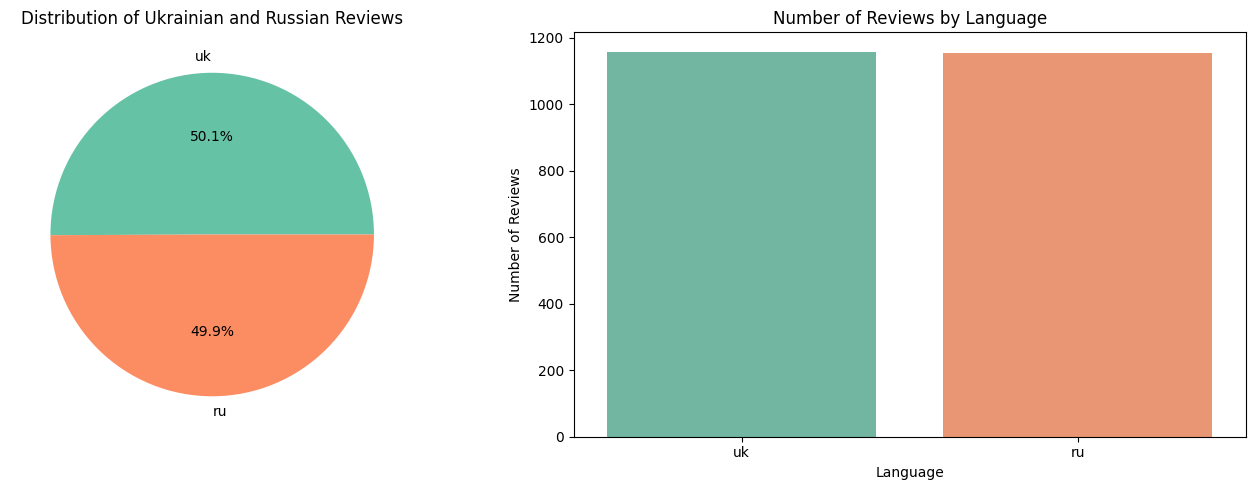

Number of reviews by language:
 Language
uk    1159
ru    1156
Name: count, dtype: int64


In [9]:
# Count and visualize reviews by language
# Automatically detect language if not already provided, then display results as a pie chart and bar plot

# --------------------------
# 1. Automatically detect language if "Language" column does not exist
# --------------------------
if "Language" not in full_df.columns:
    full_df["Language"] = full_df["Cleaned_Text"].apply(lambda x: detect(x))

# --------------------------
# 2. Count the number of reviews by language
# --------------------------
language_counts = full_df["Language"].value_counts()
languages = language_counts.index
num_languages = len(languages)

# --------------------------
# 3. Choose a color palette with enough colors for all languages
# --------------------------
palette_colors = sns.color_palette("Set2", n_colors=num_languages)

plt.figure(figsize=(14,5))

# --------------------------
# 4. Pie chart showing language distribution
# --------------------------
plt.subplot(1,2,1)
plt.pie(language_counts, labels=languages, autopct="%1.1f%%", colors=palette_colors)
plt.title("Distribution of Ukrainian and Russian Reviews")

# --------------------------
# 5. Countplot showing number of reviews per language
# --------------------------
plt.subplot(1,2,2)
sns.countplot(x="Language", data=full_df, palette=palette_colors)
plt.title("Number of Reviews by Language")
plt.ylabel("Number of Reviews")
plt.xlabel("Language")

plt.tight_layout()
plt.show()

# --------------------------
# 6. Print the number of reviews for each language
# --------------------------
print("Number of reviews by language:\n", language_counts)

In [11]:
# 1️⃣ Use KMeans to split the data into 2 clusters
# --------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
full_df['cluster'] = kmeans.fit_predict(full_df[['x', 'y']])  # or ['x','y','z'] for 3D

# --------------------------
# 2️⃣ Analyze class distribution within each cluster
# --------------------------
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

print("Class distribution per cluster:\n")
for i in range(2):
    cluster_labels = full_df.loc[full_df['cluster']==i, label_cols]
    # Sum the number of 1s in each class
    class_counts = cluster_labels.sum()
    print(f"Cluster {i}:")
    print(class_counts.sort_values(ascending=False))
    print("\n")

# --------------------------
# 3️⃣ Display a few example texts from each cluster
# --------------------------
for i in range(2):
    print(f"Cluster {i} example texts:")
    examples = full_df.loc[full_df['cluster']==i, 'Cleaned_Text'].head(5).tolist()
    for ex in examples:
        print("-", ex)
    print("\n")

# --------------------------
# 4️⃣ (Optional) Analyze language distribution if the 'Language' column exists
# --------------------------
if 'Language' in full_df.columns:
    print("Language distribution per cluster:\n")
    print(full_df.groupby('cluster')['Language'].value_counts())

Class distribution per cluster:

Cluster 0:
Education_Quality              104.0
Attitude_Towards_Students       95.0
Academic_Process_Management     71.0
Corruption                      70.0
Campus_conditions               47.0
dtype: float64


Cluster 1:
Education_Quality              80.0
Attitude_Towards_Students      63.0
Corruption                     60.0
Campus_conditions              57.0
Academic_Process_Management    37.0
dtype: float64


Cluster 0 example texts:
- 1 зміст навчання і предмети не відповідають спеціальності навіщо вища математика для спеціальності менеджменту 2 навчання формальне бо хто за копійки буде старатись навчати 3 проросійські викладачи як пазюра
- працюють лише старі як перед смертю або ті кого нікуди більш не беруть зарплати копічані якість всього така сама
- якщо вже така річ прохання контролювати проректора з господарської роботи ту якак є зараз і буде пізніше завжи хлібне місце при любій людині яка буде займати цю посади і начальників служб які об

##### Clustering Conclusions

**Language as the dominant factor**

- **Cluster 0** → almost entirely Ukrainian reviews (1145/1149 ≈ 99.6%).  
- **Cluster 1** → almost entirely Russian reviews (1152/1166 ≈ 99.2%).  

**Interpretation:** The clustering is almost perfectly aligned with the **language of the reviews**.

## Checking Category Distribution Across Languages

Before training a multi-label classification model, it's important to ensure that **categories are not biased by language**.  
If certain categories appear predominantly in one language (e.g., Russian vs. Ukrainian), the model might learn to **predict the language rather than the actual features** of the review.  

The following analysis examines how each review category is distributed between Ukrainian and Russian reviews.


In [27]:
from langdetect import detect

# Define a safe detection function
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Apply to the review text column
labeled_df["Language"] = labeled_df["Review Text"].apply(detect_lang)

In [28]:
# List of target categories
label_cols = ["Attitude_Towards_Students",
              "Campus_conditions",
              "Corruption",
              "Academic_Process_Management",
              "Education_Quality"]

# -----------------------------
# 1️⃣ Group reviews by language and sum category labels
# -----------------------------
category_distribution = labeled_df.groupby("Language")[label_cols].sum()

# -----------------------------
# 2️⃣ Calculate percentage distribution per language
# -----------------------------
category_distribution_pct = category_distribution.div(category_distribution.sum(axis=1), axis=0) * 100

# -----------------------------
# 3️⃣ Display results
# -----------------------------
print("Absolute counts per language:")
print(category_distribution)

print("\nPercentage distribution per language:")
print(category_distribution_pct)

Absolute counts per language:
          Attitude_Towards_Students  Campus_conditions  Corruption  \
Language                                                             
bg                              0.0                0.0         1.0   
ru                             63.0               58.0        58.0   
uk                             95.0               46.0        71.0   

          Academic_Process_Management  Education_Quality  
Language                                                  
bg                                0.0                0.0  
ru                               37.0               79.0  
uk                               71.0              105.0  

Percentage distribution per language:
          Attitude_Towards_Students  Campus_conditions  Corruption  \
Language                                                             
bg                         0.000000           0.000000  100.000000   
ru                        21.355932          19.661017   19.661017   
uk   

## Category Distribution Across Languages

The table shows the **percentage of each review category per language**.  

| Language | Attitude_Towards_Students | Campus_conditions | Corruption | Academic_Process_Management | Education_Quality |
|----------|---------------------------|-----------------|-----------|----------------------------|-----------------|
| bg       | 0.0%                      | 0.0%            | 100.0%    | 0.0%                       | 0.0%            |
| ru       | 21.4%                     | 19.7%           | 19.7%     | 12.5%                      | 26.8%           |
| uk       | 24.5%                     | 11.9%           | 18.3%     | 18.3%                      | 27.1%           |

### Interpretation

- **Balanced distribution in Russian and Ukrainian reviews:**  
  Most categories appear in both languages with relatively similar percentages.  

- **Potential outlier – Bulgarian (`bg`):**  
  Only "Corruption" is present (100%), but the sample size is likely very small.  

- **No single category dominates in one language:**  
  - For Russian (`ru`), Education_Quality is slightly higher (26.8%).  
  - For Ukrainian (`uk`), Education_Quality is also slightly higher (27.1%), and Attitude_Towards_Students is relatively strong (24.5%).  

- **Conclusion:**  
The dataset is **reasonably balanced across languages**, meaning the model is **less likely to learn language-specific biases** and more likely to focus on semantic features of the reviews.

# Embeddings (distiluse-base-multilingual-cased-v1)

### t-SNE with Embeddings

Next, we will build a t-SNE visualization based on **embeddings**.  
Unlike TF-IDF, which captures only word frequency and is sensitive to language, embeddings encode **contextual meaning of tokens**.  

This implies that:  
- The model operates on semantic representations, independent of the language.  
- Different languages do not create an “artificial gap” in the feature space.  
- Embeddings preserve semantic similarity across languages, so reviews with similar meaning can appear close to each other even if written in different languages.  

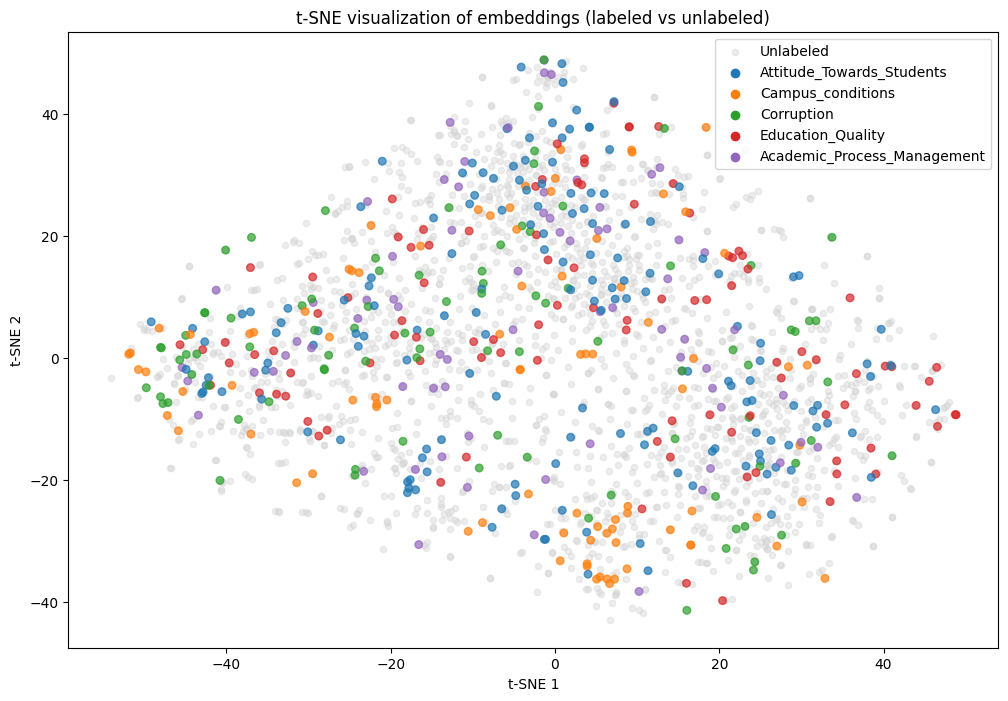

In [12]:
# Embeddings (SentenceTransformer "distiluse-base-multilingual-cased-v1")
texts = full_df["Cleaned_Text"]
model = SentenceTransformer("distiluse-base-multilingual-cased-v1")
embeddings = model.encode(texts)

label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

# Labeled reviews → create mask
mask_labeled = full_df[label_cols].notna().any(axis=1)

# Single-class labels for visualization: e.g., choose the first active class
labels = full_df.loc[mask_labeled, label_cols].idxmax(axis=1)  # name of the first class with value 1

# Dimensionality reduction
from sklearn.manifold import TSNE

# 1. Reduce embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca', max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)

# Add 2D coordinates to full_dataset
full_df["x"] = embeddings_2d[:, 0]
full_df["y"] = embeddings_2d[:, 1]

# 2. Masks for labeled and unlabeled reviews
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

mask_labeled = full_df[label_cols].notna().any(axis=1)
mask_unlabeled = ~mask_labeled
# 3. Assign a color for each class
labels_series = full_df.loc[mask_labeled, label_cols].idxmax(axis=1)  # first active class
unique_labels = labels_series.unique()
palette = sns.color_palette("tab10", len(unique_labels))
color_dict = dict(zip(unique_labels, palette))
colors = labels_series.map(color_dict)

# 4. Plot scatterplot
plt.figure(figsize=(12, 8))

# Unlabeled reviews (gray)
plt.scatter(full_df.loc[mask_unlabeled, "x"],
            full_df.loc[mask_unlabeled, "y"],
            c="lightgray", alpha=0.4, s=20, label="Unlabeled")

# Labeled reviews (colored)
plt.scatter(full_df.loc[mask_labeled, "x"],
            full_df.loc[mask_labeled, "y"],
            c=colors, alpha=0.7, s=30)

# Legend for labeled classes
for label, color in color_dict.items():
    plt.scatter([], [], c=[color], label=label)
plt.legend()
plt.title("t-SNE visualization of embeddings (labeled vs unlabeled)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

# Observation:
The clustering of embeddings reveals **three** distinct clusters.
Next, we will examine the nature of these clusters:

- If clustering corresponds to thematic grouping, it may indicate that embeddings capture underlying topics.
- If multiple classes dominate within the same cluster, it could suggest a strong semantic overlap — in this case, merging such classes might be considered.

In [17]:
# --------------------------
# 1 Generate t-SNE coordinates (2D)
# --------------------------
features = embeddings  # або TF-IDF / embeddings
tsne = TSNE(n_components=2, random_state=42, init='pca')
full_df[['x','y']] = tsne.fit_transform(features)

# --------------------------
# 2 Apply KMeans clustering
# --------------------------
kmeans_tsne = KMeans(n_clusters=3, random_state=42)
full_df['tsne_cluster'] = kmeans_tsne.fit_predict(full_df[['x','y']])

# 3 Language distribution per cluster
print("Language distribution per t-SNE cluster:")
print(full_df.groupby("tsne_cluster")["Language"].value_counts())

# 4 Class distribution per cluster
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

print("\nClass distribution per t-SNE cluster:")
for cluster_id in sorted(full_df["tsne_cluster"].unique()):
    cluster_labels = full_df.loc[full_df["tsne_cluster"] == cluster_id, label_cols]
    print(f"\nCluster {cluster_id}:")
    print(cluster_labels.sum().sort_values(ascending=False))

# 5 Example texts from each cluster (stable random sampling)
for cluster_id in sorted(full_df["tsne_cluster"].unique()):
    print(f"\nCluster {cluster_id} example texts:")
    examples = full_df.loc[full_df["tsne_cluster"] == cluster_id, "Cleaned_Text"].sample(5, random_state=42).tolist()
    for ex in examples:
        print("-", ex)

Language distribution per t-SNE cluster:
tsne_cluster  Language
0             uk          675
              ru          102
1             uk          481
              ru          211
2             ru          843
              uk            3
Name: count, dtype: int64

Class distribution per t-SNE cluster:

Cluster 0:
Education_Quality              81.0
Attitude_Towards_Students      60.0
Academic_Process_Management    49.0
Corruption                     34.0
Campus_conditions              33.0
dtype: float64

Cluster 1:
Corruption                     54.0
Attitude_Towards_Students      44.0
Education_Quality              43.0
Campus_conditions              32.0
Academic_Process_Management    28.0
dtype: float64

Cluster 2:
Education_Quality              60.0
Attitude_Towards_Students      54.0
Corruption                     42.0
Campus_conditions              39.0
Academic_Process_Management    31.0
dtype: float64

Cluster 0 example texts:
- театр починається з вішалки а внз з прийма

## Clustering Conclusions  (distiluse-base-multilingual-cased-v1)

### 1. Language as the main factor  

- **Cluster 0** → predominantly **Ukrainian reviews** (675 uk vs. 102 ru ≈ 86.9% Ukrainian).  
- **Cluster 1** → **mixed cluster** (481 uk vs. 211 ru ≈ 69.5% Ukrainian).  
- **Cluster 2** → predominantly **Russian reviews** (843 ru vs. 3 uk ≈ 99.6% Russian).  

**Interpretation:**  
The primary axis of separation in the t-SNE space is **language**.  
- Cluster 0 groups mostly Ukrainian reviews.  
- Cluster 2 is almost entirely Russian.  
- Cluster 1 represents a mixed distribution of both languages.  

---

### 2. Topic similarity  

- All thematic categories are **present in every cluster**.  
- Only slight shifts in dominance are observed:  
  - Cluster 0 → more **Education Quality** and **Attitude Towards Students**.  
  - Cluster 1 → more **Corruption** and **Attitude Towards Students**.  
  - Cluster 2 → more **Education Quality** and **Attitude Towards Students** again.  

**Interpretation:**  
Clustering does **not** correspond to clear thematic separation.  
Instead, it primarily reflects **language** and **stylistic variation** rather than distinct problem categories.  

---

### 3. Length hypothesis  

- **Cluster 1** → tends to contain **shorter, direct reviews**  
  (e.g., quick comments on corruption, teacher quality, or brief student feedback).  
- **Cluster 0** and **Cluster 2** → tends to contain **longer, multi-paragraph reviews**  
  (e.g., complaints about administration, campus conditions, or detailed descriptions of issues).  

**Next step:**  
Compute the **average review length (in words) per cluster** to validate this hypothesis statistically.  

In [19]:
# Calculate the length of each review in words
full_df["review_length"] = full_df["Cleaned_Text"].apply(lambda x: len(str(x).split()))

# Group by t-SNE clusters and compute summary statistics
length_stats = full_df.groupby("tsne_cluster")["review_length"].agg(["mean", "median", "min", "max", "count"])

# Display the statistics
print(length_stats)

                   mean  median  min  max  count
tsne_cluster                                    
0             96.155727    89.0   11  248    777
1             22.680636    19.0    1  122    692
2             82.158392    72.0    8  224    846


### Review Length Analysis per Cluster

- **Cluster 0** →  long reviews (mean ≈ 96 words, median = 89), mostly Ukrainian-language  
- **Cluster 1** → very short reviews (mean ≈ 23 words, median = 19), mixed language
- **Cluster 2** → long reviews (mean ≈ 82 words, median = 72), mostly Russian-language  

**Interpretation:**  
The separation in t-SNE space is influenced not only by **language**, but also by **review length**.  
t-SNE captures both factors simultaneously.

**Summary of clusters:**  
- **Cluster 0** → Ukrainian long-length reviews  
- **Cluster 1** → very short reviews, mixed language  
- **Cluster 2** → Russian long-length reviews

### Will create a **boxplot** or **violin plot** for each cluster to visually illustrate the differences in review lengths. 
### This will make it easier to see how short, medium, and long reviews are distributed across clusters.

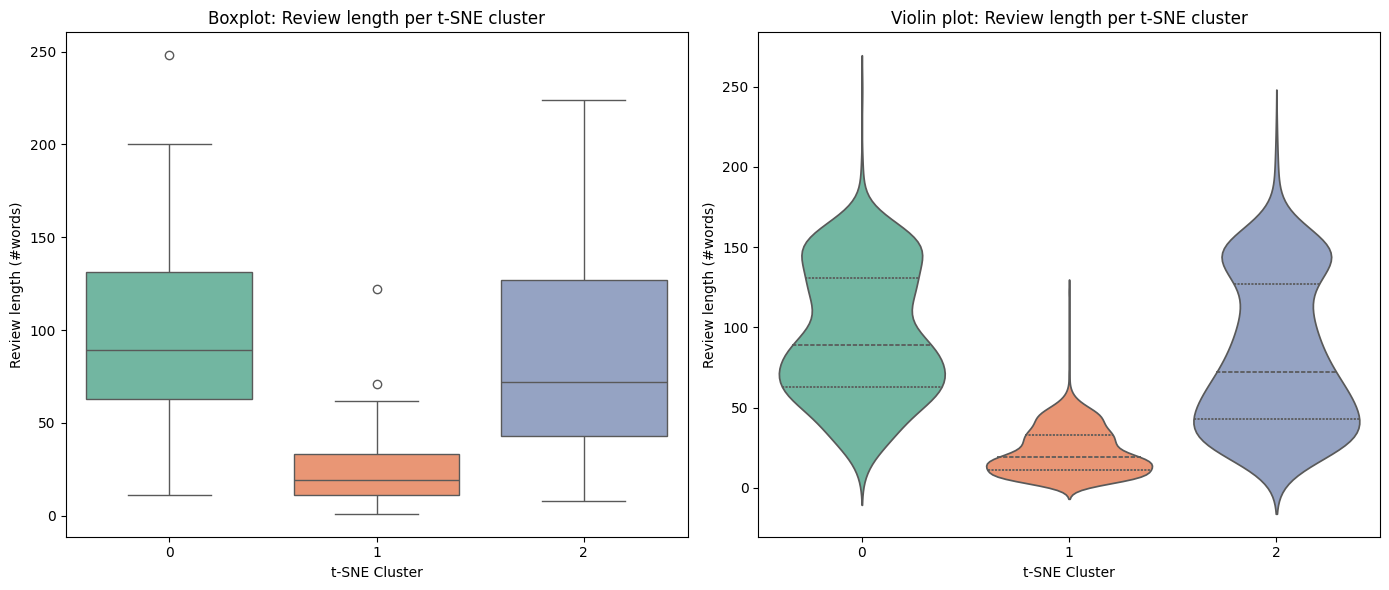

In [23]:
# --------------------------
# 1️⃣ Create a column with review length in words
# --------------------------
full_df["Review_Length"] = full_df["Cleaned_Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(14,6))

# --------------------------
# 2️⃣ Boxplot per cluster (no FutureWarning)
# --------------------------
plt.subplot(1,2,1)
sns.boxplot(x="tsne_cluster", y="Review_Length", hue="tsne_cluster", data=full_df, dodge=False, palette="Set2", legend=False)
plt.title("Boxplot: Review length per t-SNE cluster")
plt.xlabel("t-SNE Cluster")
plt.ylabel("Review length (#words)")

# --------------------------
# 3️⃣ Violin plot per cluster (no FutureWarning)
# --------------------------
plt.subplot(1,2,2)
sns.violinplot(x="tsne_cluster", y="Review_Length", hue="tsne_cluster", data=full_df, dodge=False, palette="Set2", inner="quartile", legend=False)
plt.title("Violin plot: Review length per t-SNE cluster")
plt.xlabel("t-SNE Cluster")
plt.ylabel("Review length (#words)")

plt.tight_layout()
plt.show()

# Embeddings (paraphrase-multilingual-mpnet-base-v2 embeddings)

Batches:   0%|          | 0/73 [00:00<?, ?it/s]

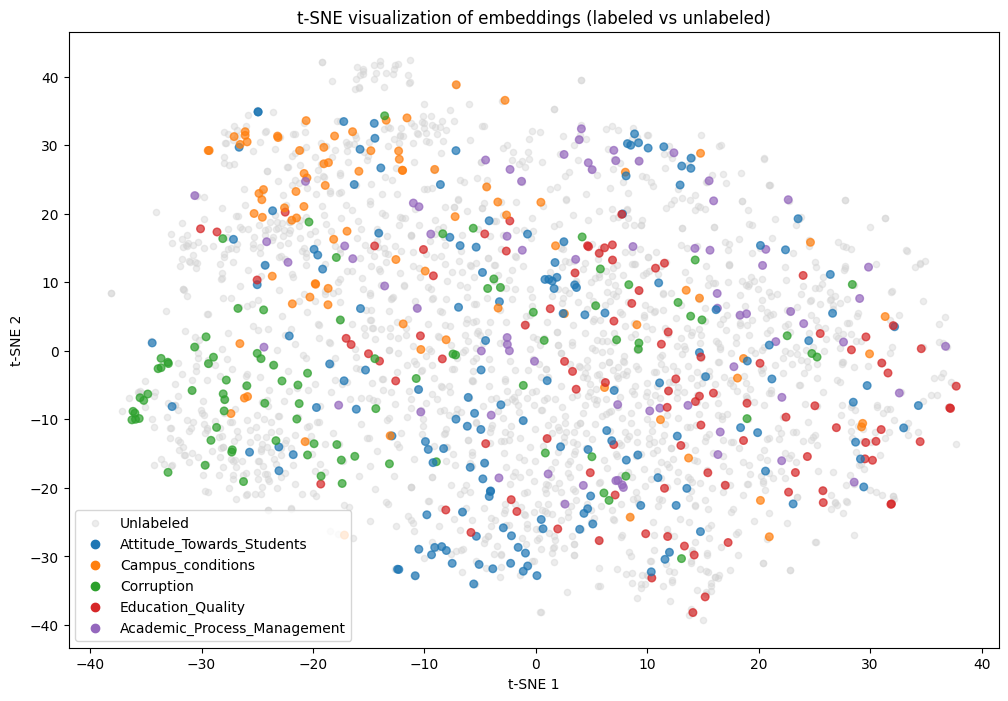

In [6]:
# Embeddings (SentenceTransformer "sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
texts = full_df["Cleaned_Text"]
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

# Labeled reviews → create mask
mask_labeled = full_df[label_cols].notna().any(axis=1)

# Single-class labels for visualization: e.g., choose the first active class
labels = full_df.loc[mask_labeled, label_cols].idxmax(axis=1)  # name of the first class with value 1

# Dimensionality reduction
from sklearn.manifold import TSNE

# 1. Reduce embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto', init='pca', max_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)

# Add 2D coordinates to full_dataset
full_df["x"] = embeddings_2d[:, 0]
full_df["y"] = embeddings_2d[:, 1]

# 2. Masks for labeled and unlabeled reviews
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

mask_labeled = full_df[label_cols].notna().any(axis=1)
mask_unlabeled = ~mask_labeled

# 3. Assign a color for each class
labels_series = full_df.loc[mask_labeled, label_cols].idxmax(axis=1)  # first active class
unique_labels = labels_series.unique()
palette = sns.color_palette("tab10", len(unique_labels))
color_dict = dict(zip(unique_labels, palette))
colors = labels_series.map(color_dict)

# 4. Plot scatterplot
plt.figure(figsize=(12, 8))

# Unlabeled reviews (gray)
plt.scatter(full_df.loc[mask_unlabeled, "x"],
            full_df.loc[mask_unlabeled, "y"],
            c="lightgray", alpha=0.4, s=20, label="Unlabeled")

# Labeled reviews (colored)
plt.scatter(full_df.loc[mask_labeled, "x"],
            full_df.loc[mask_labeled, "y"],
            c=colors, alpha=0.7, s=30)

# Legend for labeled classes
for label, color in color_dict.items():
    plt.scatter([], [], c=[color], label=label)
plt.legend()
plt.title("t-SNE visualization of embeddings (labeled vs unlabeled)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### Observation:

The clustering of embeddings reveals **five distinct clusters**.  
Next, we will examine the nature of these clusters:  

- If clustering corresponds to **thematic grouping**, it may indicate that embeddings capture underlying topics.  
- If multiple classes dominate within the same cluster, it could suggest a strong semantic overlap — in this case, merging such classes might be considered.  

In [10]:
# --------------------------
# 1 Generate t-SNE coordinates (2D)
# --------------------------
features = embeddings  # або TF-IDF / embeddings
tsne = TSNE(n_components=2, random_state=42, init='pca')
full_df[['x','y']] = tsne.fit_transform(features)

# --------------------------
# 2 Apply KMeans clustering
# --------------------------
kmeans_tsne = KMeans(n_clusters=5, random_state=42)
full_df['tsne_cluster'] = kmeans_tsne.fit_predict(full_df[['x','y']])

# 3 Language distribution per cluster
print("Language distribution per t-SNE cluster:")
print(full_df.groupby("tsne_cluster")["Language"].value_counts())

# 4 Class distribution per cluster
label_cols = ["Attitude_Towards_Students", "Campus_conditions", 
              "Corruption", "Academic_Process_Management", "Education_Quality"]

print("\nClass distribution per t-SNE cluster:")
for cluster_id in sorted(full_df["tsne_cluster"].unique()):
    cluster_labels = full_df.loc[full_df["tsne_cluster"] == cluster_id, label_cols]
    print(f"\nCluster {cluster_id}:")
    print(cluster_labels.sum().sort_values(ascending=False))

# 5 Example texts from each cluster (stable random sampling)
for cluster_id in sorted(full_df["tsne_cluster"].unique()):
    print(f"\nCluster {cluster_id} example texts:")
    examples = full_df.loc[full_df["tsne_cluster"] == cluster_id, "Cleaned_Text"].sample(5, random_state=42).tolist()
    for ex in examples:
        print("-", ex)

Language distribution per t-SNE cluster:
tsne_cluster  Language
0             ru          237
              uk          205
1             ru          244
              uk          197
2             uk          226
              ru          217
3             uk          274
              ru          244
4             uk          257
              ru          214
Name: count, dtype: int64

Class distribution per t-SNE cluster:

Cluster 0:
Education_Quality              63.0
Academic_Process_Management    23.0
Attitude_Towards_Students      22.0
Corruption                     10.0
Campus_conditions               7.0
dtype: float64

Cluster 1:
Campus_conditions              57.0
Attitude_Towards_Students      20.0
Academic_Process_Management    14.0
Education_Quality              13.0
Corruption                     11.0
dtype: float64

Cluster 2:
Corruption                     71.0
Attitude_Towards_Students      20.0
Education_Quality              17.0
Campus_conditions              16.0
A

## t-SNE visualization after K-Means clustering (5 clusters)

C:\Users\Користувач\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


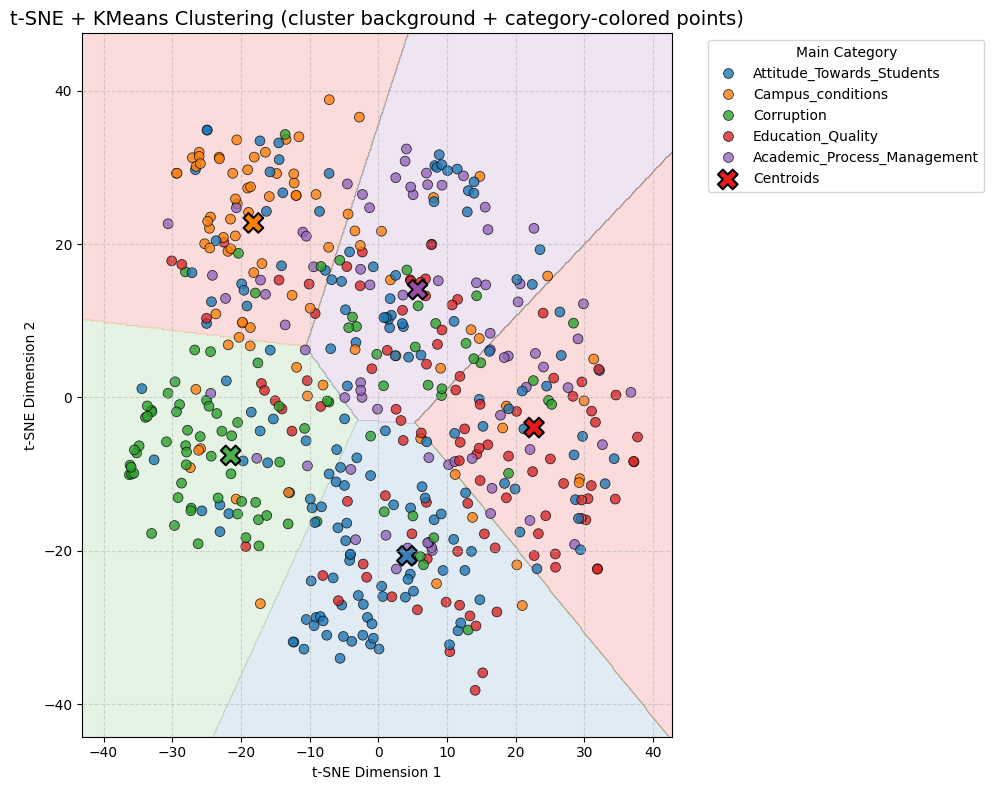

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ----------------------------------------
# 1. Define color palette for cluster background
# ----------------------------------------
cluster_colors = {
    0: "#e41a1c",  # red
    1: "#ff7f00",  # orange
    2: "#4daf4a",  # green
    3: "#377eb8",  # blue
    4: "#984ea3"   # purple
}

# ----------------------------------------
# 2. Prepare labeled subset for colored points
# ----------------------------------------
df_vis = full_df[label_cols + ['x', 'y', 'tsne_cluster']].dropna(subset=label_cols)
df_vis['main_category'] = df_vis[label_cols].idxmax(axis=1)

unique_labels = df_vis['main_category'].unique()
palette = sns.color_palette("tab10", len(unique_labels))
color_map = dict(zip(unique_labels, palette))

# ----------------------------------------
# 3. Build background (cluster regions)
# ----------------------------------------
x_min, x_max = full_df["x"].min() - 5, full_df["x"].max() + 5
y_min, y_max = full_df["y"].min() - 5, full_df["y"].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict cluster assignment for every grid point
Z = kmeans_tsne.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot background colors for clusters
plt.figure(figsize=(10, 8))
plt.contourf(
    xx, yy, Z,
    cmap=ListedColormap([cluster_colors[i] for i in sorted(cluster_colors.keys())]),
    alpha=0.15
)

# ----------------------------------------
# 4. Plot points colored by main category
# ----------------------------------------
sns.scatterplot(
    data=df_vis,
    x="x",
    y="y",
    hue="main_category",
    palette=color_map,
    s=50,
    alpha=0.8,
    edgecolor="black"
)

# ----------------------------------------
# 5. Add cluster centroids
# ----------------------------------------
centroids = kmeans_tsne.cluster_centers_
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    s=200, c=[cluster_colors[i] for i in range(5)],
    marker="X", edgecolor="black", linewidth=1.5, label="Centroids"
)

# ----------------------------------------
# 6. Style the plot
# ----------------------------------------
plt.title("t-SNE + KMeans Clustering (cluster background + category-colored points)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Main Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 🧩 **Conclusion**

All cluster colors correspond to the labeled categories.
Although some categories are mixed across clusters, a clear tendency can be observed — certain colors dominate within specific clusters, indicating semantic similarity among texts belonging to the same thematic group.

## Clustering Conclusions (paraphrase-multilingual-mpnet-base-v2 embeddings)

### 1. Language distribution  

- **Cluster 0** → mixed, slightly more **Russian** (237 ru vs. 205 uk)  
- **Cluster 1** → mixed, slightly more **Russian** (244 ru vs. 197 uk)  
- **Cluster 2** → mixed, slightly more **Ukrainian** (225 uk vs. 218 ru)  
- **Cluster 3** → predominantly **Ukrainian** (274 uk vs. 244 ru)  
- **Cluster 4** → predominantly **Ukrainian** (258 uk vs. 213 ru)  

**Interpretation:**  
Unlike previous embeddings, clusters do **not separate strictly by language**.  
There is still a tendency for some clusters to have more Ukrainian or Russian reviews, but overall **language is not the main axis of separation**.

---

### 2. Topic similarity  

- Each cluster contains multiple categories, with certain topics slightly dominating:  
  - **Cluster 0** → mostly **Education Quality**  
  - **Cluster 1** → mostly **Campus Conditions**  
  - **Cluster 2** → mostly **Corruption**  
  - **Cluster 3** → mostly **Attitude Towards Students** and **Education Quality**  
  - **Cluster 4** → mostly **Academic Process Management** and **Education Quality**  

**Interpretation:**  
Clusters reflect **semantic similarity of topics** more than language or review length.  
This indicates that **paraphrase-multilingual-mpnet-base-v2 embeddings capture meaning/context** effectively.  

---

### 3. Comparison to previous embeddings  

- Earlier embeddings (e.g., distiluse-base-multilingual-cased-v1) produced clusters largely driven by **language** and **length**.  
- **paraphrase-multilingual-mpnet-base-v2** embeddings produce clusters that align **more closely with review topics** rather than just surface-level features.  

**Conclusion:**  
For **multi-language review analysis**, **paraphrase-multilingual-mpnet-base-v2** provides a **better semantic representation**, making it more suitable for tasks like **topic discovery** or **visualization of thematic clusters**.